#**Retail Sales Performance & Trend Analysis**

Retail businesses generate large volumes of transactional data that can provide valuable insights into sales trends, product performance, and regional demand patterns. Analyzing this data helps organizations make informed decisions regarding inventory management, pricing strategies, and market expansion.

In this project, retail sales data is analyzed to identify key revenue drivers, evaluate product category performance, and uncover trends across different regions and time periods. The analysis focuses on extracting actionable insights that can support strategic business decisions.

# **Project setup & library import**

Following libraries are imported:

**Pandas** *for data processing*

**NumPy** *for numerical operations*

**Matplotlib & Seaborn** *for visual analytics*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#**Data Loading**
*The retail sales dataset is loaded into a Pandas Dataframe for analysis*

In [ ]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


#**Data Overview & Exploratory Inspection**

*A preliminary analysis is conducted to examine rows and columns of dataset, data types of each feature and summary*

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


#**Date Format Inspection**
*The format of 'Order Date' column is examined to ensure proper datetime conversion*

In [ ]:
df['Order Date'].head(10)

,Order Date
0,08/11/2017
1,08/11/2017
2,12/06/2017
3,11/10/2016
4,11/10/2016
5,09/06/2015
6,09/06/2015
7,09/06/2015
8,09/06/2015
9,09/06/2015


#**Data Preprocessing & Feature Engineering**
*Date columns are converted into datetime format to enable time- series analysis*

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Create time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October


#**Data Cleaning & Validation**
*The dataset is examined for missing values, & duplicate data.*

In [ ]:
# Missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Duplicate data
duplicate_count = df.duplicated().sum()
print("\nDuplicate Records:", duplicate_count)

df = df.drop_duplicates()

Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
dtype: int64

Duplicate Records: 0


#**Yearly Sales Performance Analysis**

*Total sales are aggregated at the yearly level to evaluate long- term business growth trends.
This helps identify the best performing year and the overall revenue progression*

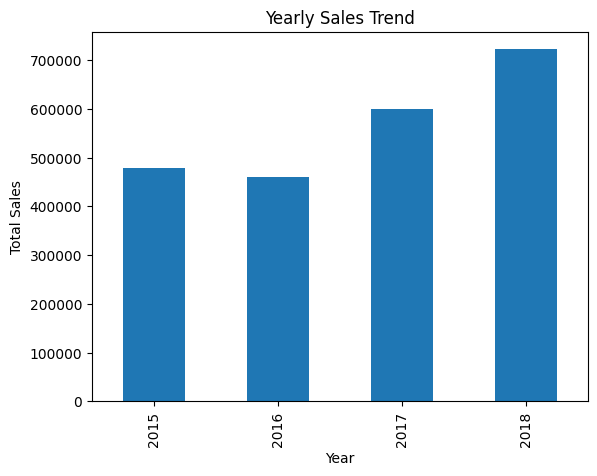

,Sales
Year,
2015,479856.2081
2016,459436.0054
2017,600192.5500
2018,722052.0192


In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure()
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales Trend")
plt.ylabel("Total Sales")
plt.show()

yearly_sales

#**Monthly Sales Trend Analysis**

*Monthly sales are ccomputed to analyze short- term fluctuations and seasonal patterns. A time- series visualization is generated to observe growth consistency and trend direction.*

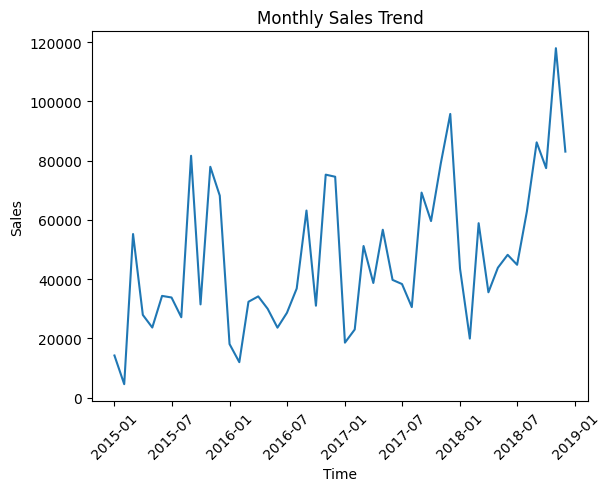

In [ ]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

monthly_sales['Year-Month'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)
)

plt.figure()
plt.plot(monthly_sales['Year-Month'], monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

#**Category- Level Sales Performance**

*Sales are grouped by product category to detrmine which category contributes the most to overall revenue.*

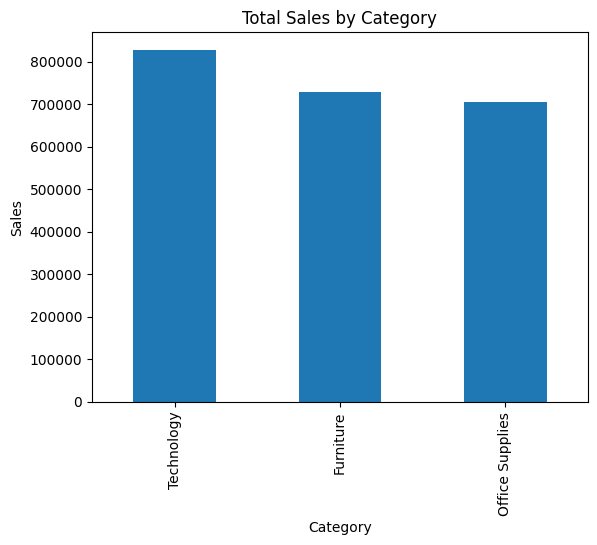

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure()
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

category_sales

#**Year- wise Category Performance Comparison**

*Sales performance is analyzed across categories for each year.*

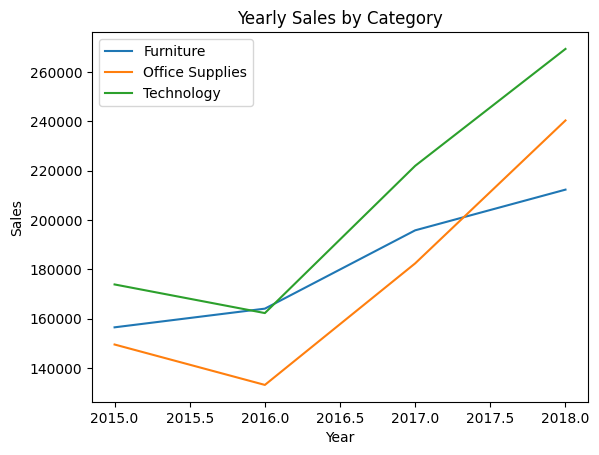

In [ ]:
category_year_sales = df.groupby(['Year', 'Category'])['Sales'].sum().reset_index()

plt.figure()
for category in category_year_sales['Category'].unique():
    subset = category_year_sales[category_year_sales['Category'] == category]
    plt.plot(subset['Year'], subset['Sales'], label=category)

plt.title("Yearly Sales by Category")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.show()

#**Regional Sales Distribution**

*Sales are analyzed across different regionns to identify geographic revenue drivers.*

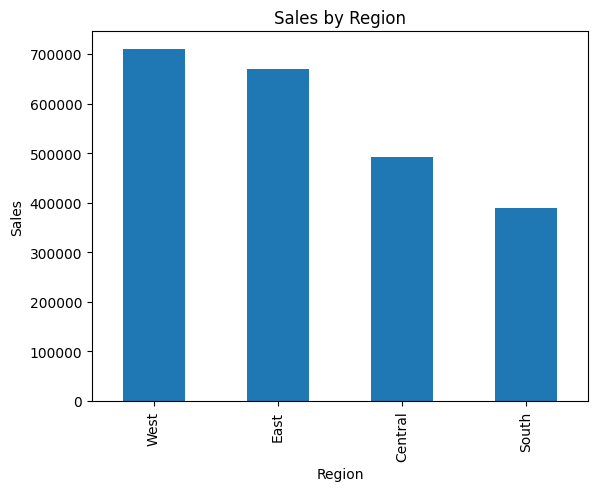

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

region_sales

#**Customer Segment Performance**

*Sales are examined by customer segment to evaluste which segment generates maximum revenue.*

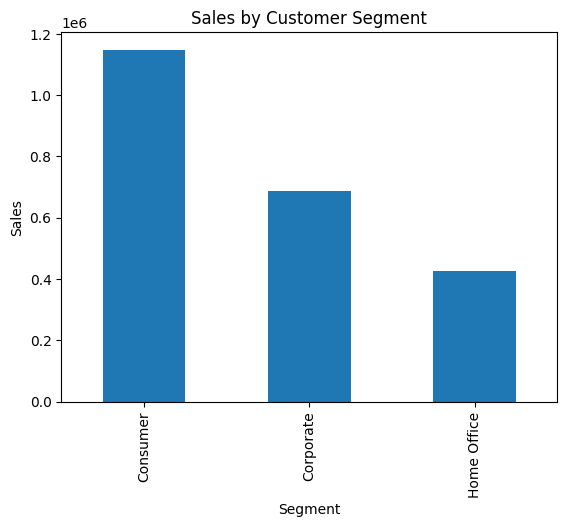

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure()
segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.ylabel("Sales")
plt.show()

segment_sales

#**Top 10 Revenue- Generating Products**

*Products are ranked based on total sales to identify best- selling items.*

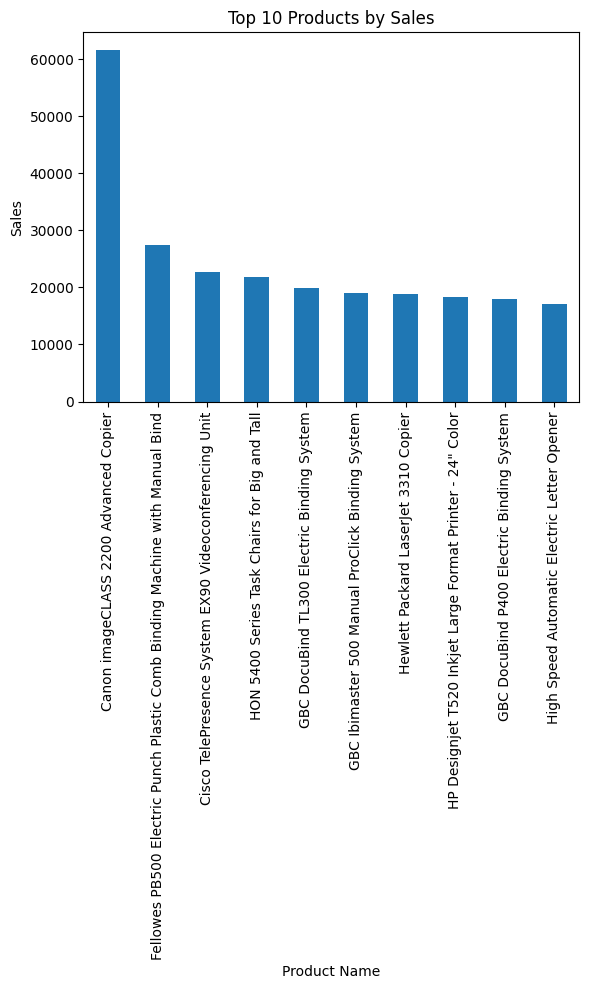

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

top_products

#**Correlation Analysis**
*A correlation matrix is generated to evaluste relationships between numeric variables.*

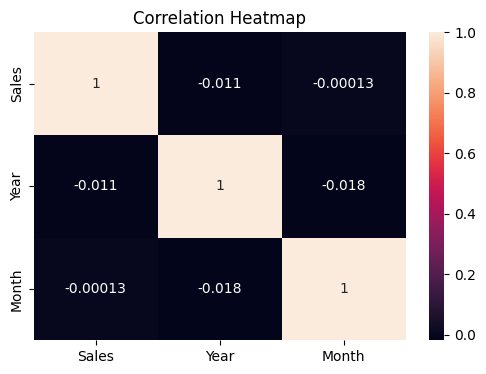

In [ ]:
import seaborn as sns
plt.figure(figsize=(6,4))
corr = df[['Sales', 'Year', 'Month']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

#**Year- over- Year (YoY) Growth Analysis**
*Percentage growth in sales is calculated year- over- year to measure business expansion rate.*

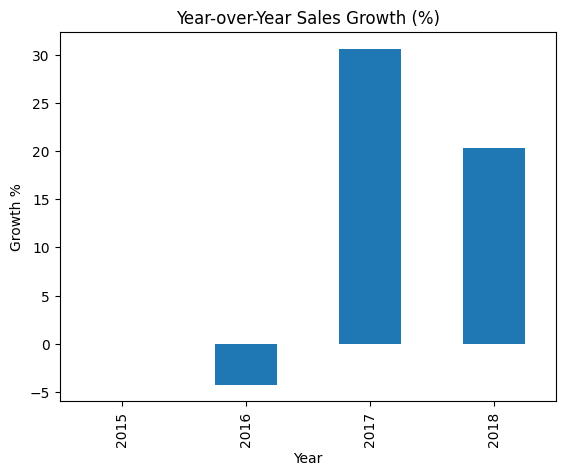

In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum()
growth = yearly_sales.pct_change() * 100
growth
plt.figure()
growth.plot(kind='bar')
plt.title("Year-over-Year Sales Growth (%)")
plt.ylabel("Growth %")
plt.show()

#**Rolling Average Trend Analysis**
*A 3- month moving average is computed to smooth short- term fluctuations and reveal underlying sales trends.*

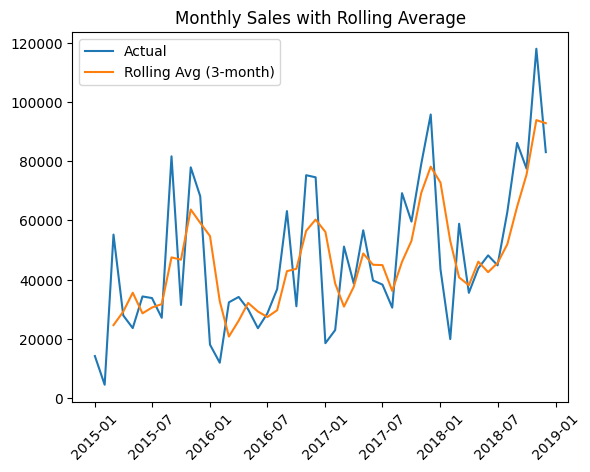

In [ ]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

monthly_sales['Year-Month'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)
)

monthly_sales = monthly_sales.sort_values('Year-Month')

monthly_sales['Rolling Avg'] = monthly_sales['Sales'].rolling(window=3).mean()

plt.figure()
plt.plot(monthly_sales['Year-Month'], monthly_sales['Sales'], label='Actual')
plt.plot(monthly_sales['Year-Month'], monthly_sales['Rolling Avg'], label='Rolling Avg (3-month)')
plt.legend()
plt.title("Monthly Sales with Rolling Average")
plt.xticks(rotation=45)
plt.show()

#**Revenue contribution by Category**
*The percentage contribution of each category to total revenue is calculated.*


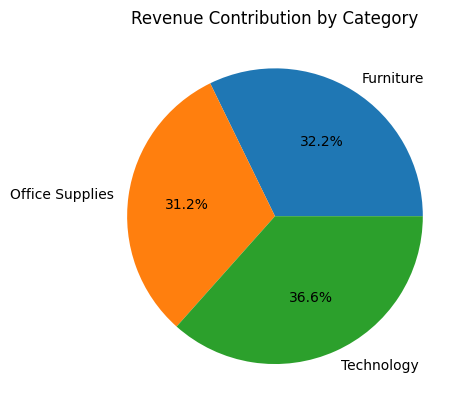

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()
category_contribution = (category_sales / category_sales.sum()) * 100
category_contribution
plt.figure()
category_contribution.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue Contribution by Category")
plt.ylabel("")
plt.show()

#**Business KPI Summary**
*Key performance indicators are calculated to understand overall business performance*

In [ ]:
total_revenue = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 2261536.78
Total Orders: 4922
Total Customers: 793
Average Order Value: 459.48


#**Key Business Insights & Conclusions**
**Major Findings:**
- Highest performing year: 2018.
- Leading category: Technology.
- Top revenue region: West.
- Consumer segment contributes highest sales.
- Consistent upward sales trend observed over time.

**Business Implications:**
- Focus expansion strategies on high-growth categories.
- Strengthen presence in top-performing regions.
- Monitor category diversification to reduce dependency risk.
